# ForecastLab — EXP-006 Baseline Forecasting

| Informasi | Detail |
|-----------|--------|
| **Project ID** | FL-002 |
| **Eksperimen** | EXP-006 |
| **Dataset** | featured_data.csv |
| **Author** | GAKUSEI Najib |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110

INPUT_PATH = '../data/featured_data.csv'
df = pd.read_csv(INPUT_PATH)
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)

target = 'PowerConsumption_Zone1'
train = df[df['Datetime'] < '2017-07-01'].copy()
test  = df[df['Datetime'] >= '2017-07-01'].copy()
print(f'Train: {len(train)}, Test: {len(test)}')

Train: 25920, Test: 26352


In [2]:
y_train = train[target].values
y_test = test[target].values

# Naive Forecast
y_pred_naive = np.roll(y_test, 1)
y_pred_naive[0] = y_train[-1]

# Moving Average (window=144 = 1 hari)
window = 144
y_pred_ma = pd.Series(y_train).rolling(window).mean().iloc[-1]
y_pred_ma = np.full(len(y_test), y_pred_ma)

print('Baseline models selesai.')

Baseline models selesai.


In [3]:
def eval_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100
    r2 = r2_score(y_true, y_pred)
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

results = [
    eval_model('Naive', y_test, y_pred_naive),
    eval_model('Moving Average', y_test, y_pred_ma)
]
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

         Model         MAE        RMSE      MAPE        R2
         Naive  411.882310  612.392208  1.275078  0.992686
Moving Average 5950.022166 7188.063451 18.932320 -0.007609


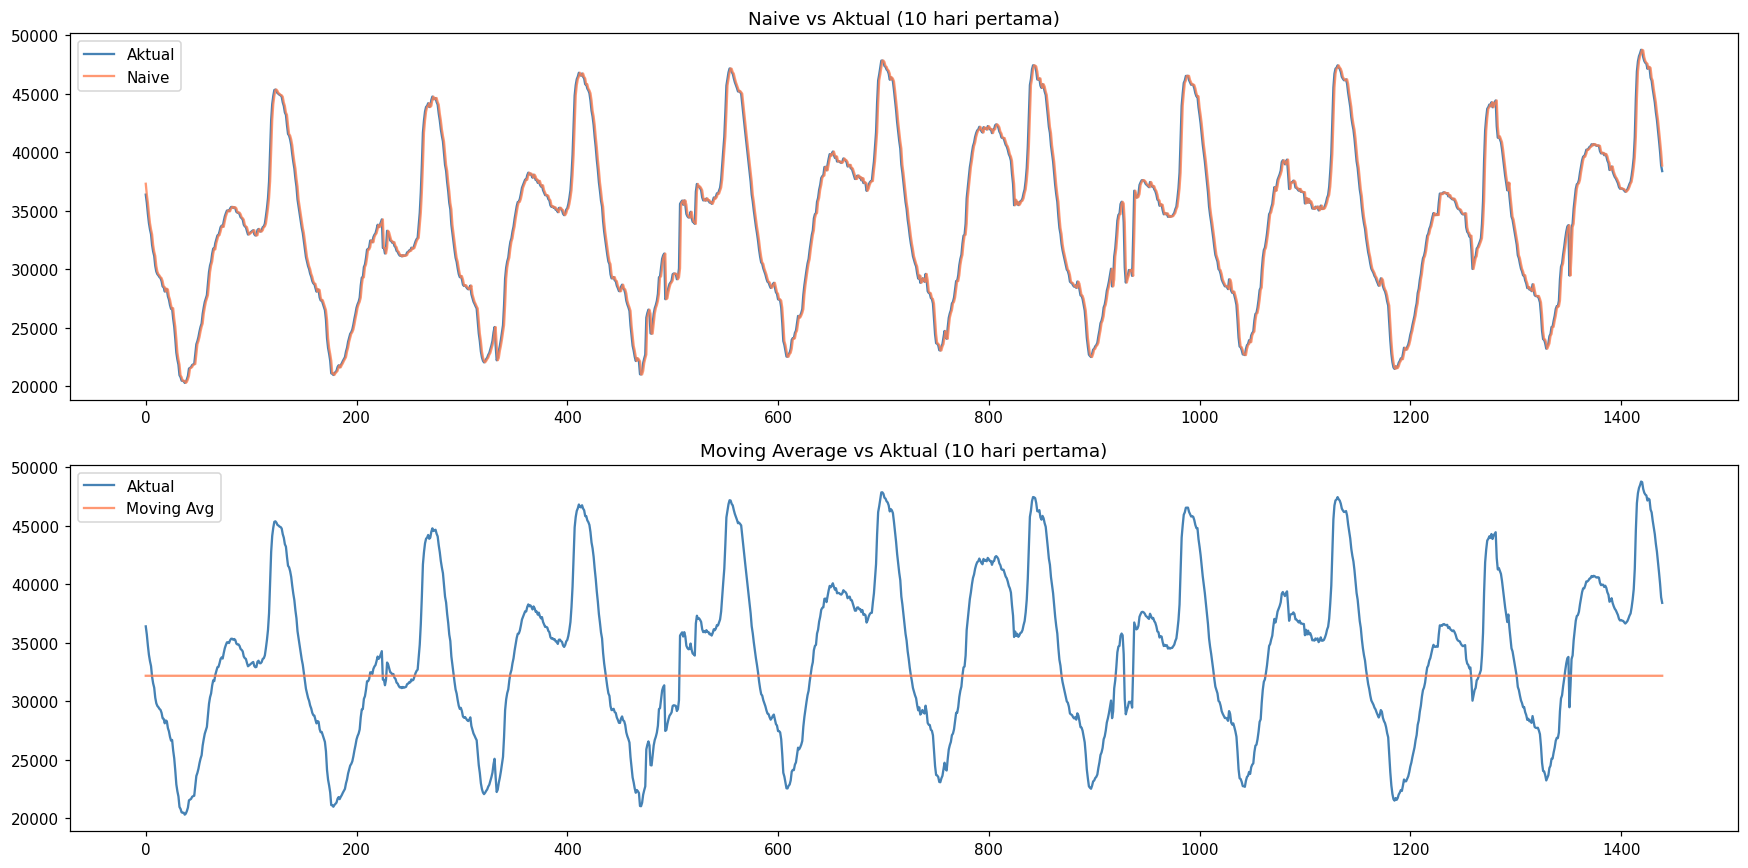

In [4]:
n_show = 1440
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
axes[0].plot(range(n_show), y_test[:n_show], label='Aktual', color='steelblue')
axes[0].plot(range(n_show), y_pred_naive[:n_show], label='Naive', color='coral', alpha=0.8)
axes[0].set_title('Naive vs Aktual (10 hari pertama)')
axes[0].legend()
axes[1].plot(range(n_show), y_test[:n_show], label='Aktual', color='steelblue')
axes[1].plot(range(n_show), y_pred_ma[:n_show], label='Moving Avg', color='coral', alpha=0.8)
axes[1].set_title('Moving Average vs Aktual (10 hari pertama)')
axes[1].legend()
plt.tight_layout()
plt.savefig('../data/baseline_01_comparison.png', bbox_inches='tight', dpi=110)
plt.show()

---
## Kesimpulan

Baseline models sebagai pembanding untuk model ML berikutnya.

**Next: EXP-007 Linear Regression**